In [ ]:
from mssm.models import *
from mssmViz.sim import *
from mssmViz.plot import *
from mssmViz.extract import eval_coverage
import pickle
import copy
import os
import dotenv
dotenv.load_dotenv()

n_cores = int(os.getenv("n_cores"))

from defaults import (
    default_gamm_kwargs,
    default_gammlss_kwargs,
    default_gsmm_kwargs,
)

default_gamm_kwargs["n_cores"] = n_cores
default_gammlss_kwargs["n_cores"] = n_cores
default_gsmm_kwargs["n_cores"] = n_cores

qefs_kwargs = copy.deepcopy(default_gsmm_kwargs)
qefs_kwargs["method"] = "qEFS"

n_sim = 1
fcoef_ratios = [0, 0.25, 0.5, 0.75]


# Sim 15 (sim 19 for Multinomial) (sim20 for Multigauss)

In [ ]:
############################# Simulation 2: Exponential #############################
sim_fams = [Gaussian(),Gamma(),Binomial(),Poisson()]
fam_names = ["Gaussian", "Gamma", "Binom", "Poisson"]
offsets = [0,0,-5,-5]

for should_correlate in [True,False]:

    for fam_name, sim_fam, b_offset in zip(fam_names,sim_fams,offsets):
        
        # Set up storage for current sim
        eta_mses = np.zeros((n_sim,1 + len(fcoef_ratios)))
        coverage = np.zeros((n_sim,1 + len(fcoef_ratios)))
        Failures = np.zeros((n_sim,1 + len(fcoef_ratios)))

        gsmm_fam = GAMLSSGSMMFamily(1,sim_fam)

        fcoef = 43 + (1 if sim_fam.twopar else 0)
        
        iterator = tqdm(range(n_sim),desc="Simulating",leave=True)
        for sim_i in iterator:

            sim_dat = sim15(500,2,c=1,seed=sim_i,family=sim_fam,
                           binom_offset = b_offset,
                           correlate=should_correlate)
            
            sim_dat.to_csv((f"./results/data/sim2_exp/sim_size:{n_sim}_fam:"
                            f"{fam_name}_corr:{should_correlate}_set:{sim_i}.csv"),index=False)

            # We need to model the mean: \mu_i - this time including a non-linear interaction
            # of variables x1 and x2
            sim_formula_m = Formula(lhs("y"),
                                [i(),f(["x0"]),f(["x1","x2"],te=True),f(["x3"])],
                                data=sim_dat)
            
            sim_i_failed = [False, *[False for _ in fcoef_ratios]]

            ############################# Fit model with EFS #############################
            model_efs = GAMM(copy.deepcopy(sim_formula_m),sim_fam)
            try:
                model_efs.fit(**default_gamm_kwargs)
            except:
                sim_i_failed[0] = True

            ############################# Fit model with qEFS #############################
            models = [model_efs]
            for rai,ratio in enumerate(fcoef_ratios):

                qefs_kwargs["structured_qefs_budget"] = int(ratio*fcoef)

                gsmm_model = GSMM(formulas=[copy.deepcopy(sim_formula_m)],family=gsmm_fam)
                
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        
                        gsmm_model.fit(**qefs_kwargs)
                except:
                    sim_i_failed[1+rai] = True

                models.append(gsmm_model)
            
            ######################################## Collect MSEs ####################################

            for mi, model in enumerate(models):

                if sim_i_failed[mi]:
                    print(f"Model {mi+1} failed at {sim_i}")
                    Failures[sim_i,mi] = 1
                    eta_mses[sim_i,mi] = np.nan
                    coverage[sim_i,mi] = np.nan
                    continue

                # Not converged but not failed outright
                if model.info.code > 0:
                    Failures[sim_i,mi] = 1
                
                #plot(model)

                pred_diff = model.preds[0].flatten() - sim_dat["eta"].values
                _,mcov,_ = eval_coverage(model,sim_dat,target=sim_dat["eta"].values)
                coverage[sim_i,mi] = mcov
                eta_mses[sim_i,mi] = np.dot(pred_diff,pred_diff)/len(pred_diff)
            
                #print(coverage[sim_i,mi],eta_mses[sim_i,mi])
            iterator.set_description_str(desc=f"MSE.: {[(float(np.round(m,decimals=4)),
                                                         float(np.round(sd,decimals=2)))
                                                         for m,sd in zip(np.mean(eta_mses[:(sim_i+1),:],axis=0),
                                                                         np.std(eta_mses[:(sim_i+1),:],axis=0))]}",
                                                                         refresh=True)
            ###################################### Save in progress results ######################################
            res = {"eta_mses":eta_mses,
                   "Failures":Failures,
                   "coverage":coverage,
                   }
            
            with open(f'./results/sim/sim2_exp/size:{n_sim}_fam:{fam_name}_corr:{should_correlate}.pickle', 'wb') as file:
                pickle.dump(res,file, protocol=pickle.HIGHEST_PROTOCOL)
        
        iterator.close()

Simulating:   0%|          | 0/1 [00:00<?, ?it/s]

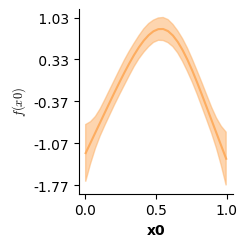

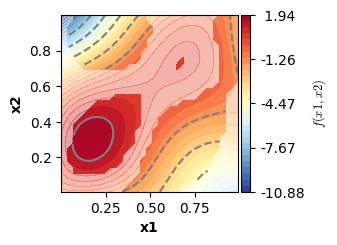

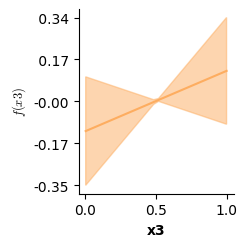

0.9873333333333333 0.024893505861645952


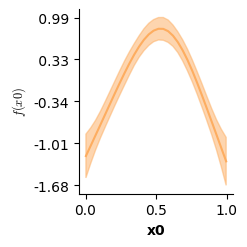

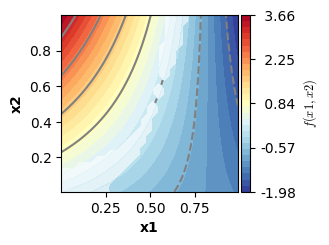

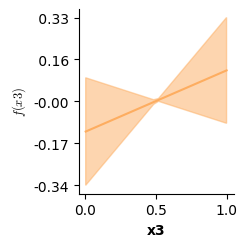

0.7473333333333333 0.13540142103766067


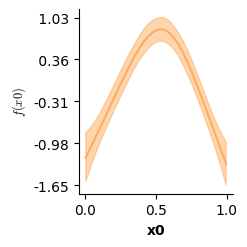

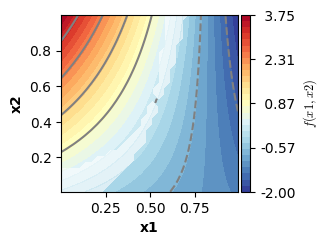

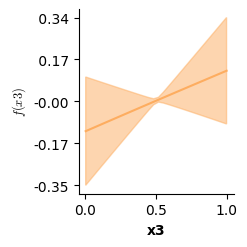

0.74 0.1366101066161796


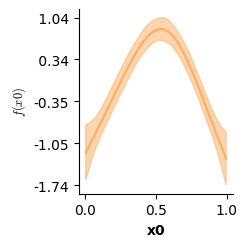

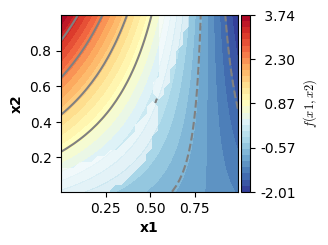

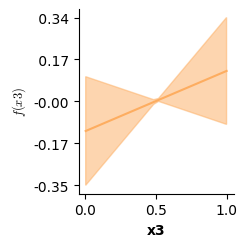

0.75 0.13719850157461783


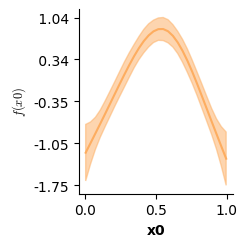

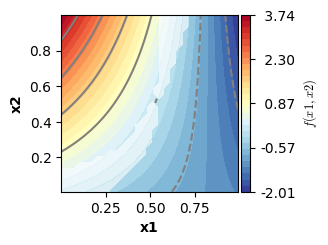

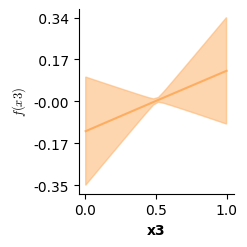

MSE.: [(0.0249, 0.0), (0.1354, 0.0), (0.1366, 0.0), (0.1372, 0.0), (0.137, 0.0)]: 100%|██████████| 1/1 [00:59<00:00, 59.79s/it]


0.7486666666666667 0.13699205326080957


Simulating:   0%|          | 0/1 [00:00<?, ?it/s]

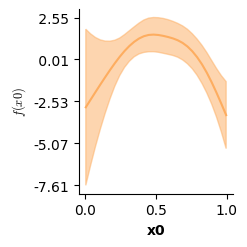

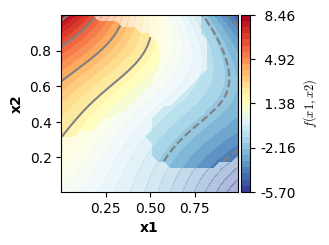

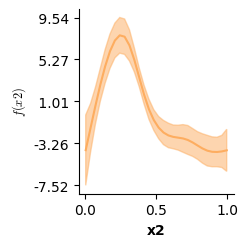

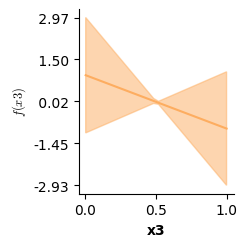

0.452 6.125390649093865


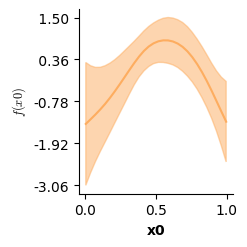

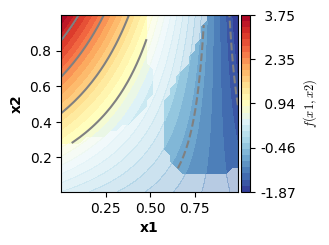

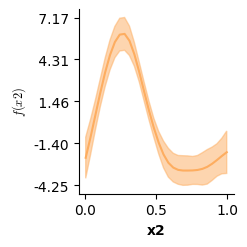

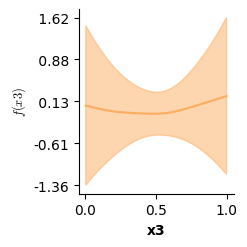

0.639 1.7724450124166553


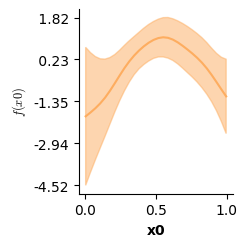

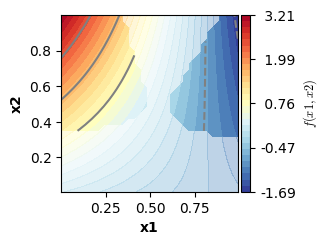

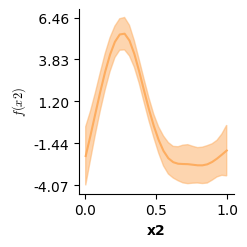

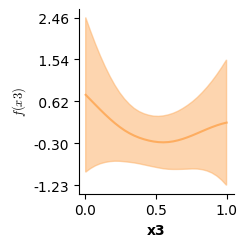

0.7875 0.9632797215289639


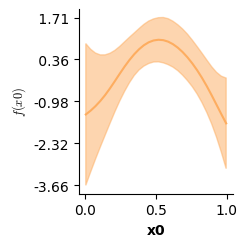

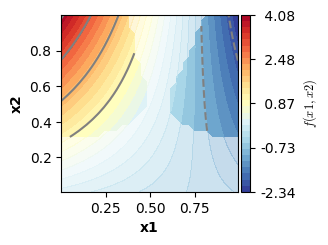

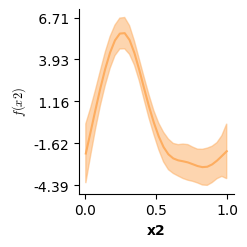

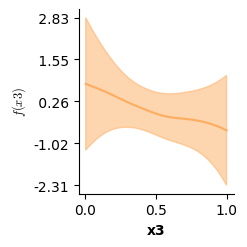

0.727 1.2780769314790712


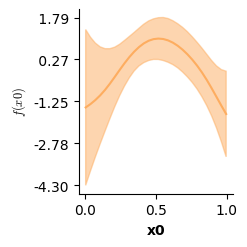

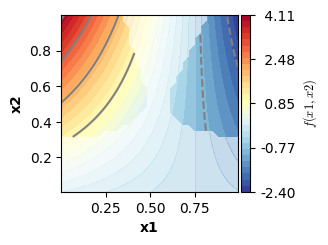

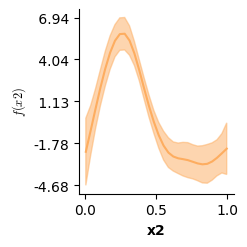

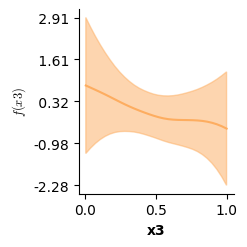

MSE.: [(6.1254, 0.0), (1.7724, 0.0), (0.9633, 0.0), (1.2781, 0.0), (1.3783, 0.0)]: 100%|██████████| 1/1 [01:42<00:00, 102.72s/it]


0.746 1.3782915026977343


Simulating:   0%|          | 0/1 [00:00<?, ?it/s]/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


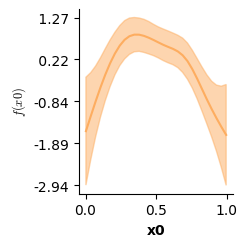

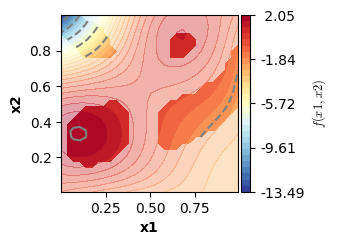

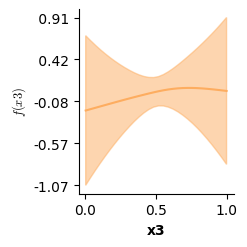

0.99 0.0919648629802857


/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


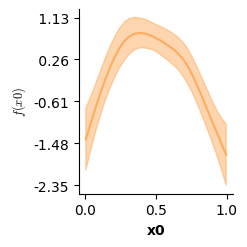

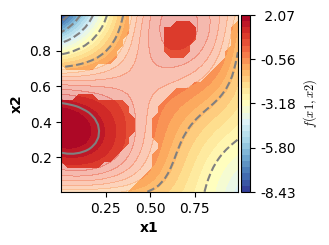

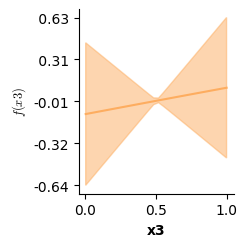

0.966 0.08621328942677382


/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


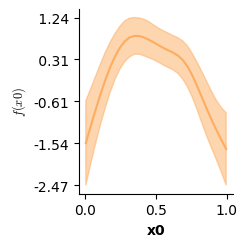

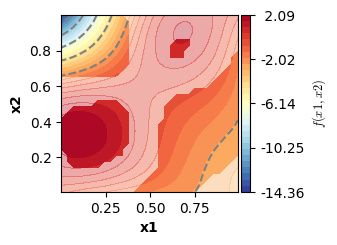

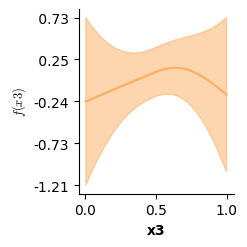

0.988 0.09499020416176067


/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


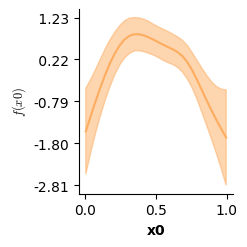

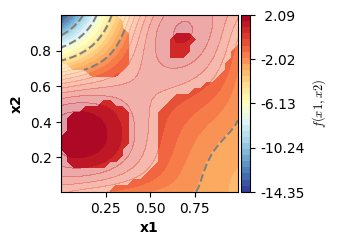

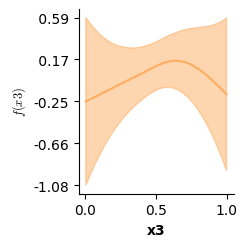

0.986 0.0939588762908633


/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


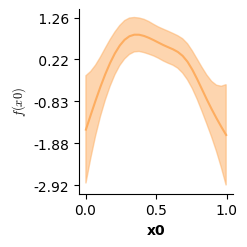

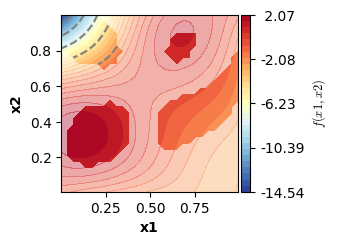

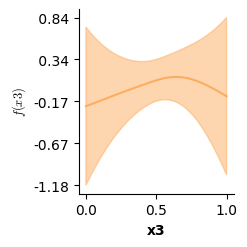

MSE.: [(0.092, 0.0), (0.0862, 0.0), (0.095, 0.0), (0.094, 0.0), (0.0943, 0.0)]: 100%|██████████| 1/1 [00:24<00:00, 24.51s/it]


0.988 0.09425655531740267


Simulating:   0%|          | 0/1 [00:00<?, ?it/s]/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


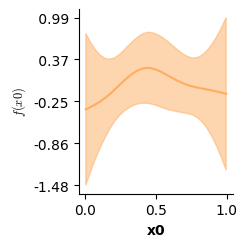

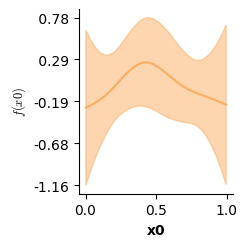

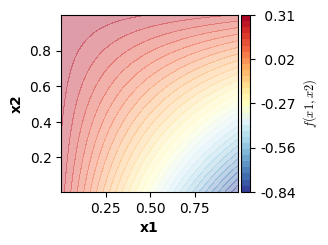

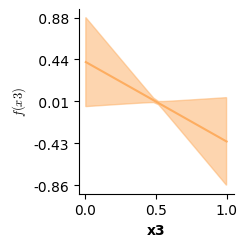

0.322 0.9232396700091597


/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


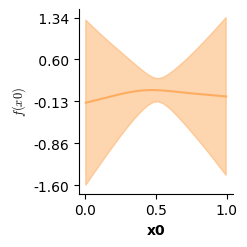

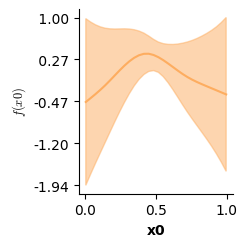

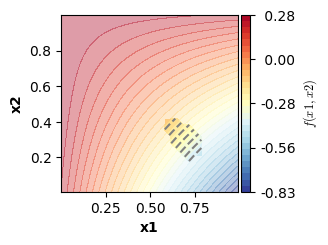

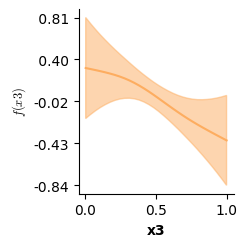

0.302 0.9058618169525694


/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


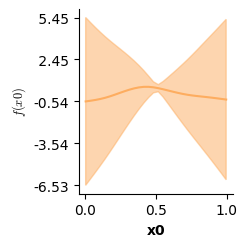

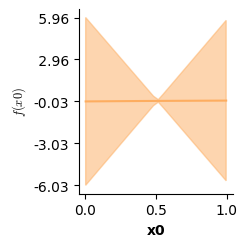

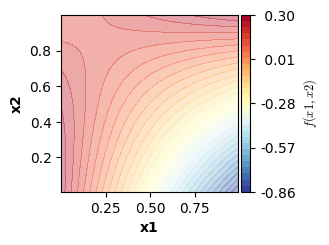

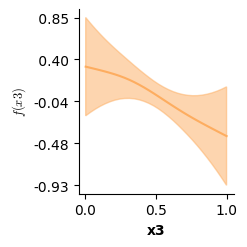

0.328 0.9334328479032424


/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


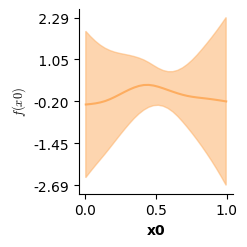

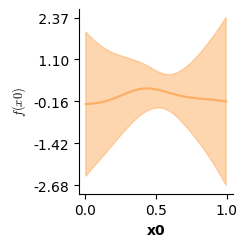

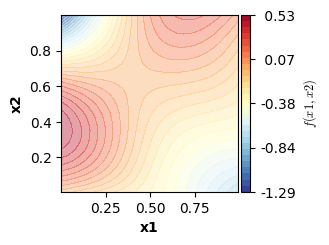

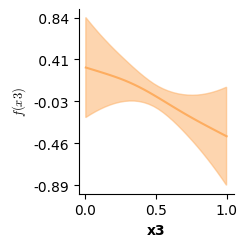

0.376 0.8241883472306679


/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


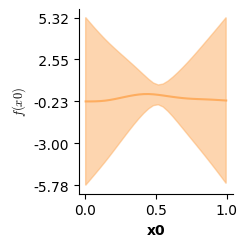

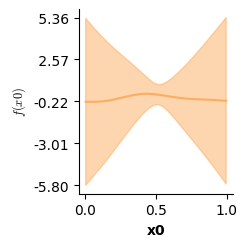

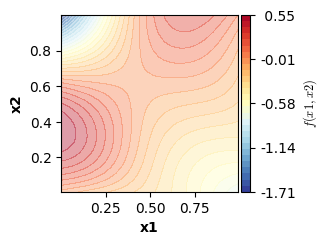

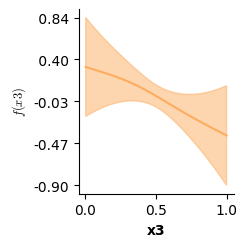

MSE.: [(0.9232, 0.0), (0.9059, 0.0), (0.9334, 0.0), (0.8242, 0.0), (0.8133, 0.0)]: 100%|██████████| 1/1 [31:23<00:00, 1883.13s/it]


0.394 0.813307357518752


Simulating:   0%|          | 0/1 [00:00<?, ?it/s]

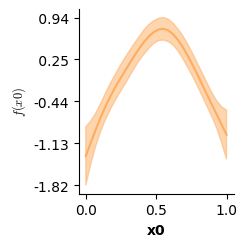

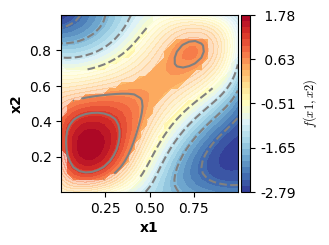

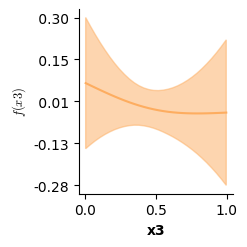

0.956 0.03366786983426555


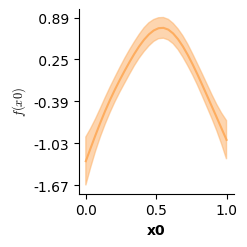

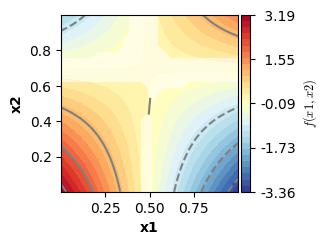

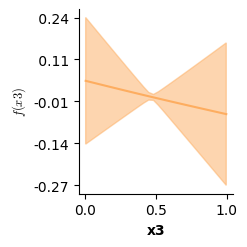

0.7486666666666667 0.17993778011473818


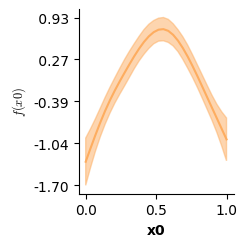

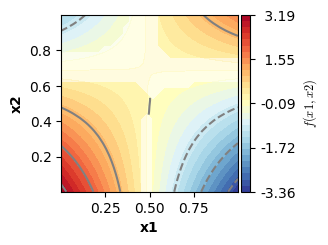

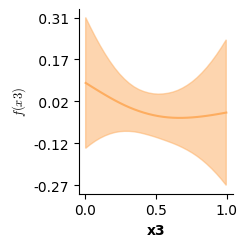

0.7553333333333333 0.1797276061051556


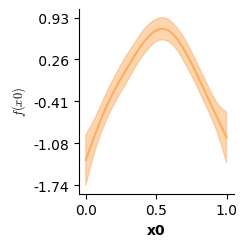

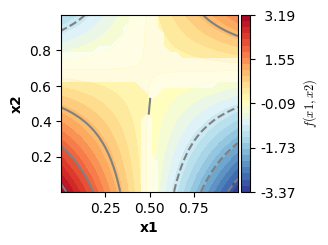

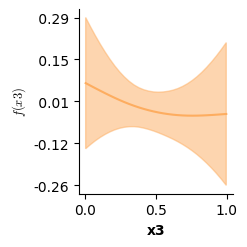

0.7613333333333333 0.17994763429521124


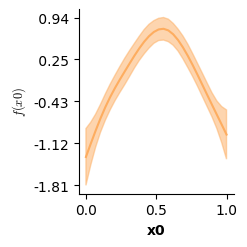

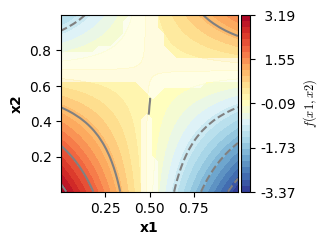

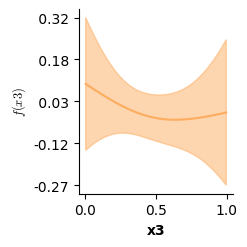

MSE.: [(0.0337, 0.0), (0.1799, 0.0), (0.1797, 0.0), (0.1799, 0.0), (0.1802, 0.0)]: 100%|██████████| 1/1 [00:41<00:00, 41.41s/it]


0.764 0.18020030514803909


Simulating:   0%|          | 0/1 [00:00<?, ?it/s]

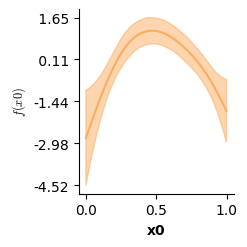

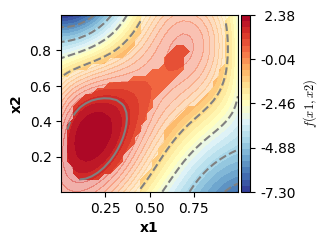

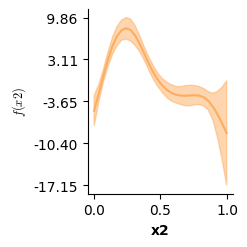

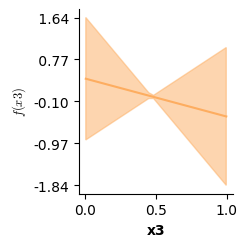

0.517 2.4075234974503625


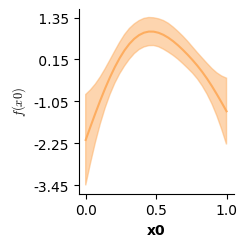

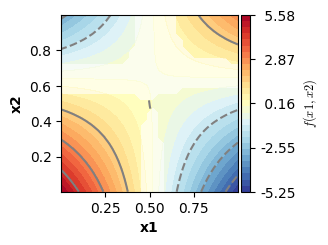

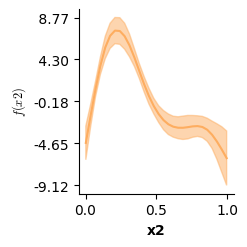

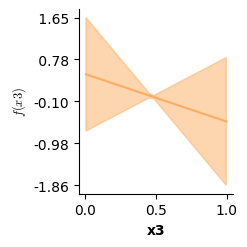

0.518 1.8337538868778651


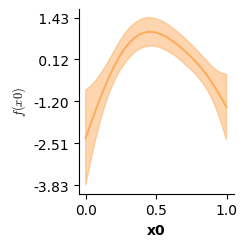

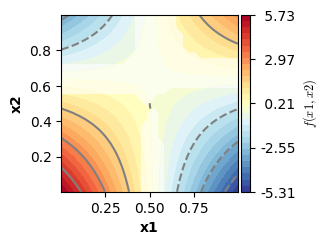

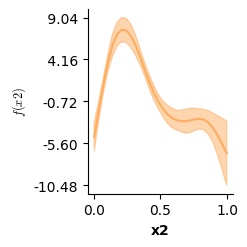

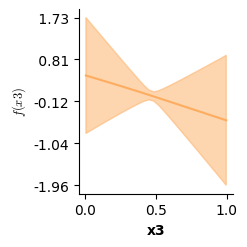

0.494 1.960447479513463


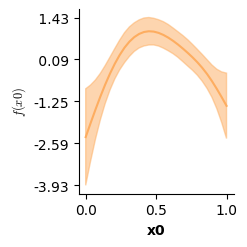

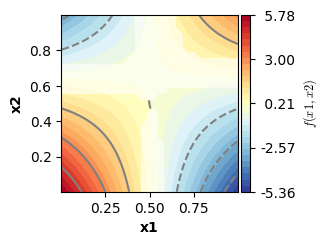

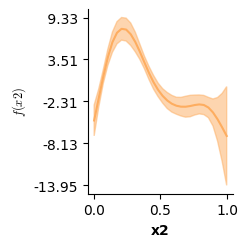

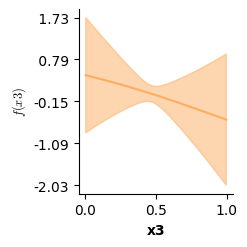

0.5055 2.030313775814524


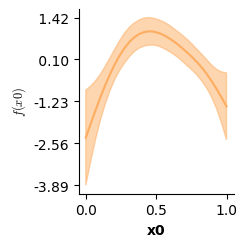

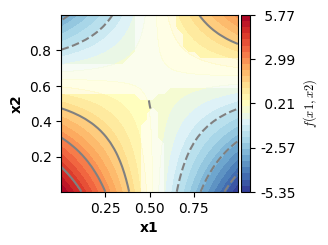

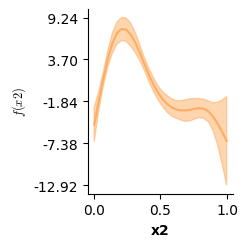

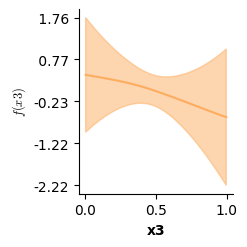

MSE.: [(2.4075, 0.0), (1.8338, 0.0), (1.9604, 0.0), (2.0303, 0.0), (2.02, 0.0)]: 100%|██████████| 1/1 [01:10<00:00, 70.40s/it]


0.501 2.0199816812895603


Simulating:   0%|          | 0/1 [00:00<?, ?it/s]/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


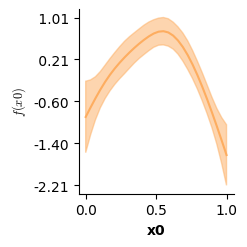

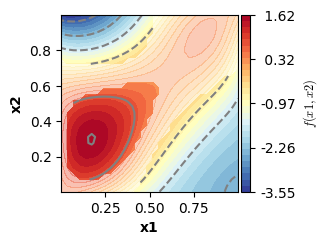

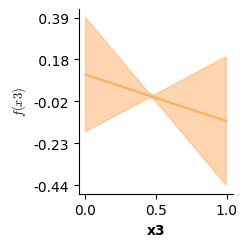

0.932 0.1702395531230497


/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


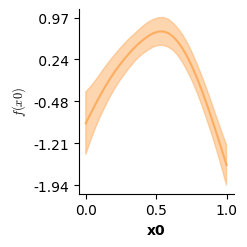

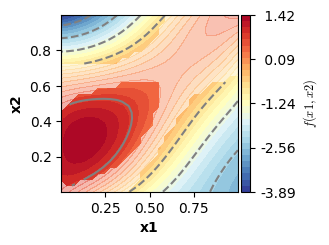

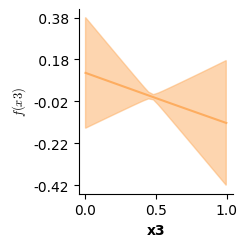

0.806 0.22133510524019218


/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


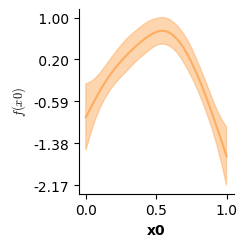

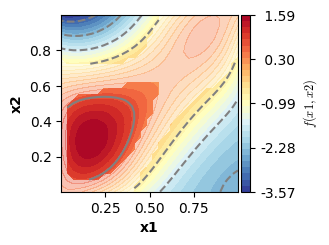

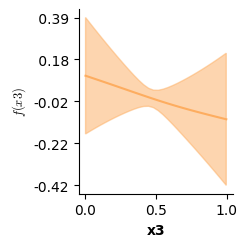

0.896 0.17402345695657026


/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


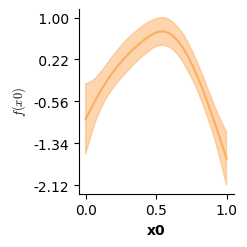

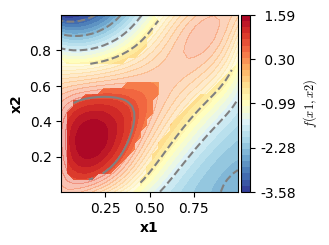

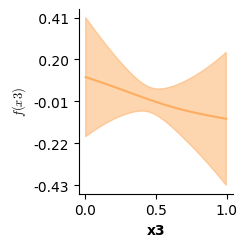

0.912 0.17405280855365493


/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


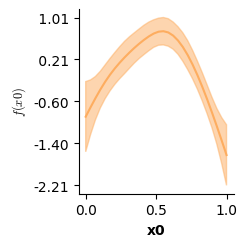

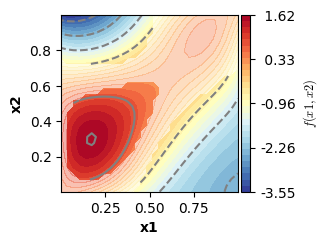

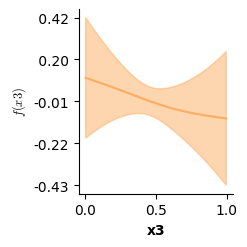

MSE.: [(0.1702, 0.0), (0.2213, 0.0), (0.174, 0.0), (0.1741, 0.0), (0.1696, 0.0)]: 100%|██████████| 1/1 [00:42<00:00, 42.92s/it]


0.934 0.16960642910347012


Simulating:   0%|          | 0/1 [00:00<?, ?it/s]/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


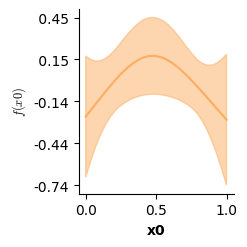

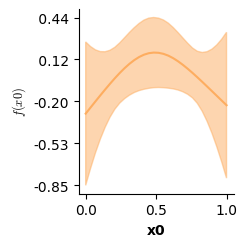

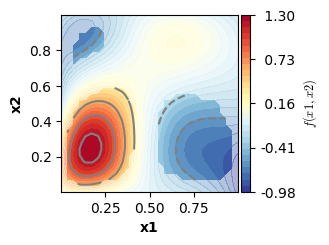

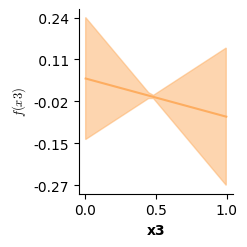

0.422 0.5979959822100199


/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


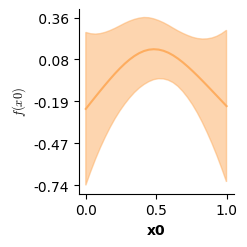

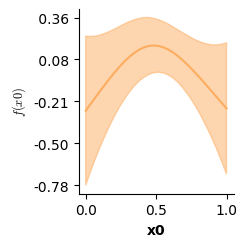

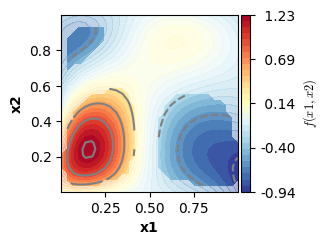

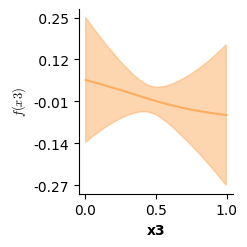

0.368 0.6266089435113272


/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


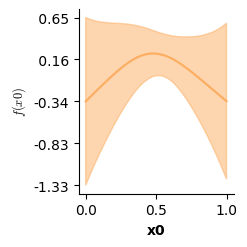

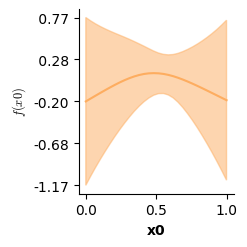

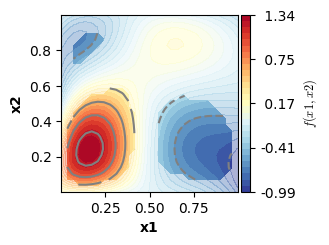

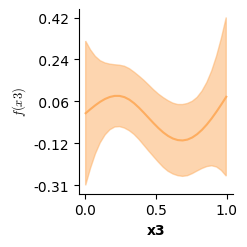

0.444 0.5950321766789419


/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


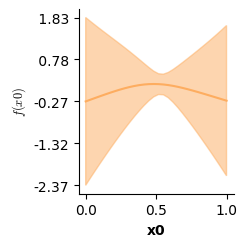

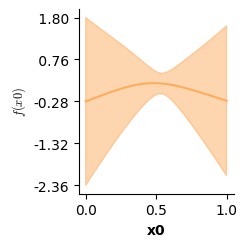

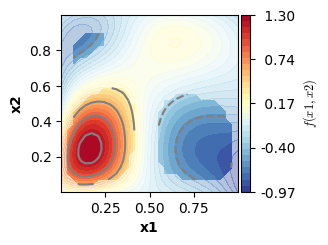

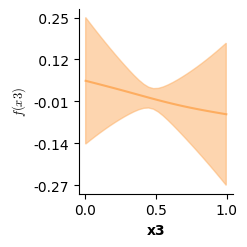

0.418 0.6002595231248858


/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:676: UserWarning: Adding colorbar to a different Figure <Figure size 236.22x236.22 with 2 Axes> than <Figure size 236.22x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(axs[axi].collections[1], cax=axins)


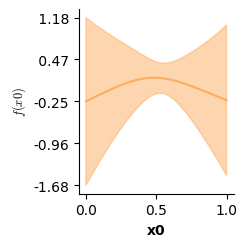

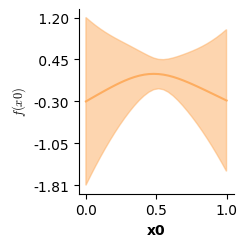

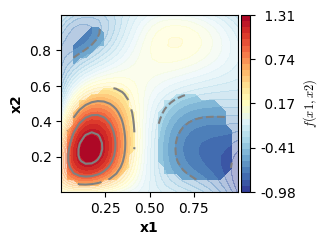

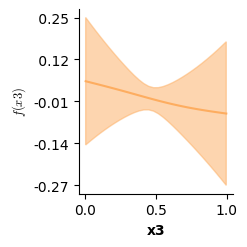

MSE.: [(0.598, 0.0), (0.6266, 0.0), (0.595, 0.0), (0.6003, 0.0), (0.597, 0.0)]: 100%|██████████| 1/1 [38:09<00:00, 2289.66s/it]

0.422 0.597040144244426


In [ ]:
############################# Simulation 2: General #############################
sim_fams = [MultiGauss(3,[Identity() for _ in range(3)]),
            MULNOMLSS(4),
            ScaledT(),
            PropHaz([0],[0])]
fam_names = ["MGauss", "Multinomial", "ScaledT", "PropHaz"]

for should_correlate in [True,False]:

    for fam_name, sim_fam in zip(fam_names,sim_fams):
        
        # Set up storage for current sim
        eta_mses = np.zeros((n_sim,1 + len(fcoef_ratios)))
        coverage = np.zeros((n_sim,1 + len(fcoef_ratios)))
        Failures = np.zeros((n_sim,1 + len(fcoef_ratios)))

        # Assign correct family for qEFS estimator
        if isinstance(sim_fam,ScaledT):
            gsmm_fam = GAMLSSGSMMFamily(1,sim_fam)
        elif isinstance(sim_fam,MULNOMLSS):
            gsmm_fam = GAMLSSGSMMFamily(4,sim_fam)
        else:
            gsmm_fam = sim_fam
        
        iterator = tqdm(range(n_sim),desc="Simulating",leave=True)
        for sim_i in iterator:

            # Get data for different families
            if isinstance(sim_fam,ScaledT):
                sim_dat = sim15(500,2,c=1,seed=sim_i,family=sim_fam,
                           binom_offset = 0,
                           correlate=should_correlate)
                
                # We need to model the mean: \mu_i - this time including a non-linear interaction
                # of variables x1 and x2
                sim_formula_m = Formula(lhs("y"),
                                    [i(),f(["x0"]),f(["x1","x2"],te=True),f(["x3"])],
                                    data=sim_dat)
                
                sim_formulas = [sim_formula_m]

                fcoef = 45 # 43 + 2 for theta

            elif isinstance(sim_fam,PropHaz):
                sim_dat = sim15(500,2,c=1,seed=sim_i,family=sim_fam,
                           binom_offset = 0.1,
                           correlate=should_correlate)
                sim_dat = sim_dat.sort_values(['y'],ascending=[False])
                sim_dat = sim_dat.reset_index(drop=True)

                u,inv = np.unique(sim_dat["y"],return_inverse=True)
                ut = np.flip(u)
                r = np.abs(inv - max(inv))
                sim_fam = PropHaz(ut=ut,r=r)
                gsmm_fam = copy.deepcopy(sim_fam)

                # Cannot have intercept!
                sim_formula_m = Formula(lhs("delta"),
                                    [f(["x0"]),f(["x1","x2"],te=True),f(["x3"])],
                                    data=sim_dat)
                
                sim_formulas = [sim_formula_m]

                fcoef = 42 # 43 - 1 for intercept
            
            elif isinstance(sim_fam,MULNOMLSS):
                # We need to specify K-1 formulas - see the `MULNOMLSS` docstring for details.
                sim_dat = sim19(500, 2, c=1, seed=sim_i, correlate=should_correlate)

                sim_formulas = []
                for k in range(4):
                    terms = [i(),f(["x1","x2"],te=True)] if k == 1 else [i(),f([f"x{k}"])]
                    sim_formulas.append(Formula(lhs("y"),terms, data=sim_dat))
                
                fcoef = 55
            else:
                # Multi Gauss case
                sim_dat = sim20(500, c=1, seed=sim_i, correlate=should_correlate)

                # We need formulas for each mean
                sim_formulas = [
                    Formula(lhs("y0"), [i(), f(["x0"])], data=sim_dat),
                    Formula(lhs("y1"), [i(), f(["x1","x2"],te=True)], data=sim_dat),
                    Formula(lhs("y2"), [i(), f(["x3"])], data=sim_dat),
                ]

                fcoef = 51 # For means and thetas
            
            sim_dat.to_csv((f"./results/data/sim2_gen/sim_size:{n_sim}_fam:"
                            f"{fam_name}_corr:{should_correlate}_set:{sim_i}.csv"),index=False)

            
            sim_i_failed = [False, *[False for _ in fcoef_ratios]]

            ############################# Fit model with EFS #############################
            if isinstance(sim_fam,ScaledT):
                model_efs = GAMM(sim_formulas[0],sim_fam)
                model_kwargs = copy.deepcopy(default_gamm_kwargs)
            elif isinstance(sim_fam,MULNOMLSS):
                model_efs = GAMMLSS(sim_formulas,sim_fam)
                model_kwargs = copy.deepcopy(default_gammlss_kwargs)
            else:
                model_efs = GSMM(sim_formulas,sim_fam)
                model_kwargs = copy.deepcopy(default_gsmm_kwargs)

            try:
                model_efs.fit(**model_kwargs)
            except:
                sim_i_failed[0] = True

            ############################# Fit model with qEFS #############################
            models = [model_efs]
            for rai,ratio in enumerate(fcoef_ratios):

                qefs_kwargs["structured_qefs_budget"] = int(ratio*fcoef)

                gsmm_model = GSMM(formulas=sim_formulas,family=gsmm_fam)
                
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        gsmm_model.fit(**qefs_kwargs)
                except:
                    sim_i_failed[1+rai] = True

                models.append(gsmm_model)
            
            ######################################## Collect MSEs ####################################

            for mi, model in enumerate(models):

                if sim_i_failed[mi]:
                    print(f"Model {mi+1} failed at {sim_i}")
                    Failures[sim_i,mi] = 1
                    eta_mses[sim_i,mi] = np.nan
                    continue

                # Not converged but not failed outright
                if model.info.code > 0:
                    Failures[sim_i,mi] = 1
                
                

                if len(model.preds) == 1:
                    pred_diff = model.preds[0].flatten() - sim_dat["eta"].values
                    _,mcov,_ = eval_coverage(model,sim_dat,target=sim_dat["eta"].values)
                    plot(model)
                else:
                    pred_diff = []
                    mcov = []
                    for pi in range(len(model.preds)):
                        pred_diff.extend(model.preds[pi].flatten() - sim_dat[f"eta{pi}"].values)
                        _,_,IN_CI = eval_coverage(model,sim_dat,
                                                dist_par=pi,
                                                target=sim_dat[f"eta{pi}"].values)
                        mcov.extend(IN_CI)
                        plot(model,dist_par=pi)
                        
                    mcov = np.sum(mcov) / len(mcov)
                    pred_diff = np.array(pred_diff)
                    
                eta_mses[sim_i,mi] = np.dot(pred_diff,pred_diff)/len(pred_diff)
                coverage[sim_i,mi] = mcov
                #print(coverage[sim_i,mi],eta_mses[sim_i,mi])
            
            iterator.set_description_str(desc=f"MSE.: {[(float(np.round(m,decimals=4)),
                                                         float(np.round(sd,decimals=2)))
                                                         for m,sd in zip(np.mean(eta_mses[:(sim_i+1),:],axis=0),
                                                                         np.std(eta_mses[:(sim_i+1),:],axis=0))]}",
                                                                         refresh=True)
            ###################################### Save in progress results ######################################
            res = {"eta_mses":eta_mses,
                   "Failures":Failures,
                   "coverage":coverage,
                   }
            
            with open(f'./results/sim/sim2_gen/size:{n_sim}_fam:{fam_name}_corr:{should_correlate}.pickle', 'wb') as file:
                pickle.dump(res,file, protocol=pickle.HIGHEST_PROTOCOL)
        
        iterator.close()